**Exp **-** 7 Clustering using K-Means and Gaussian Mixture Models** **(GMM)**

Name: Priyadharshini B

Roll no: 24BAD093

**SCENARIO 1 – CLUSTERING USING K-MEANS**

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


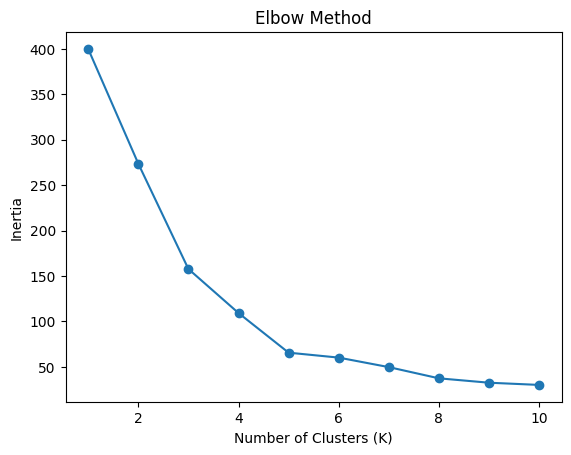

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


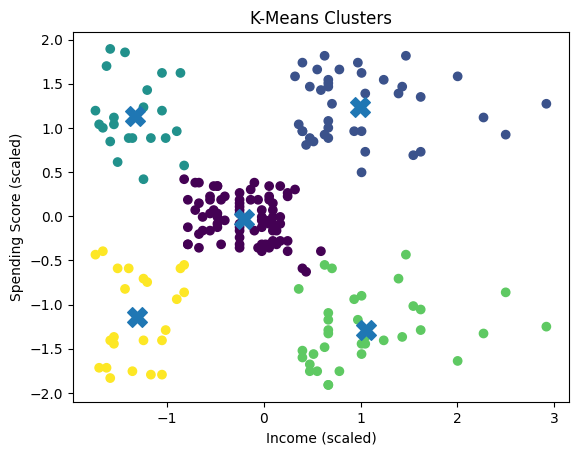

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [ ]:
# ROLL NO: 24BAD093

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 2. Load Dataset
data = pd.read_csv("/content/Mall_Customers.csv")

# 3. Preprocessing
# Check missing values
print(data.isnull().sum())

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# 5. Apply K-Means (choose K=5 based on elbow)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# 6. Add Cluster Labels
data['Cluster'] = y_kmeans

# 7. Evaluate
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, y_kmeans))

# 8. Visualization
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means Clusters")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# 9. Interpretation
print(data.groupby('Cluster').mean(numeric_only=True))

**SCENARIO 2 – CLUSTERING USING GMM**

First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


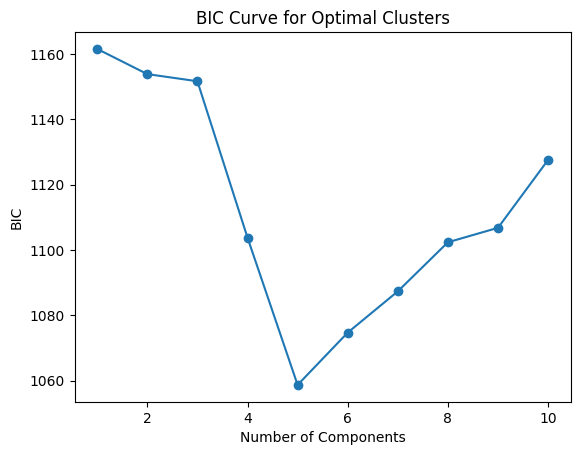


GMM Evaluation Metrics
Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245

Sample Cluster Probabilities:
 [[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


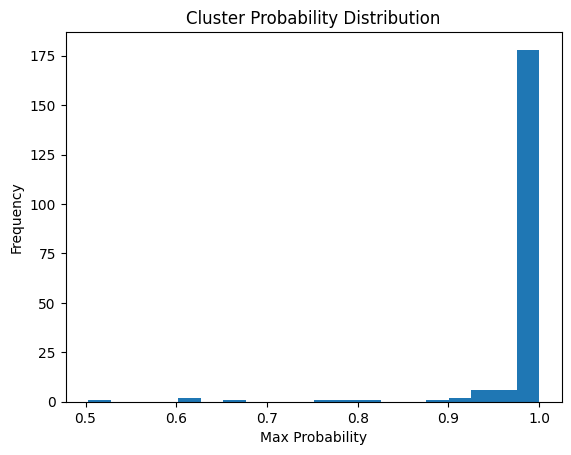

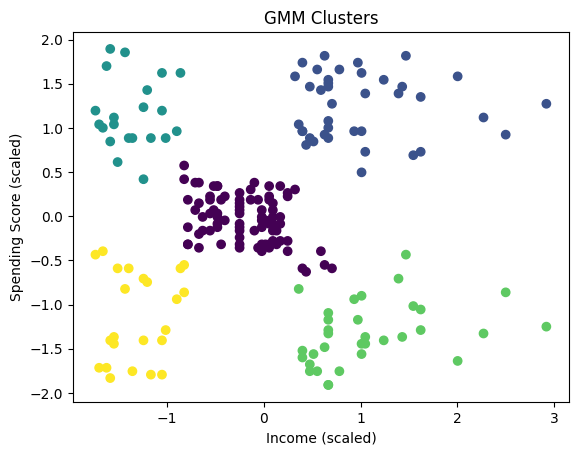

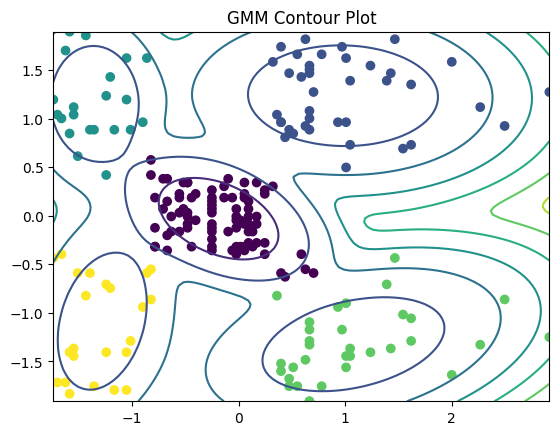

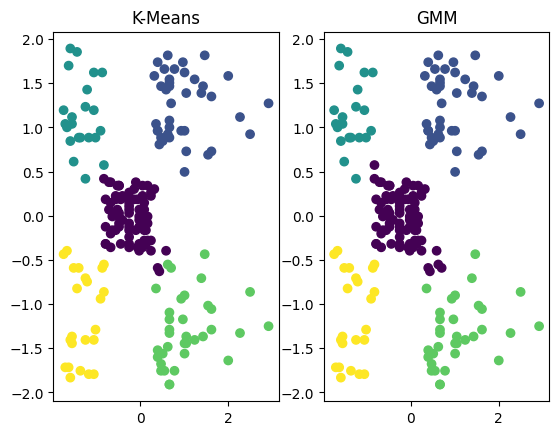


Cluster Means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.642857               49.369048
1                 86.538462               82.128205
2                 25.095238               80.047619
3                 88.818182               16.000000
4                 26.304348               20.913043


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load Dataset
data = pd.read_csv("/content/Mall_Customers.csv")

# Display basic info
print("First 5 rows:\n", data.head())
print("\nMissing Values:\n", data.isnull().sum())

# Select Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find Optimal Clusters using BIC
bic_scores = []
k_range = range(1, 11)

for k in k_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    gmm_temp.fit(X_scaled)
    bic_scores.append(gmm_temp.bic(X_scaled))

# Plot BIC Curve
plt.figure()
plt.plot(k_range, bic_scores, marker='o')
plt.title("BIC Curve for Optimal Clusters")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.show()

# Apply GMM
optimal_k = 5
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm.fit(X_scaled)

# Predict Probabilities
probs = gmm.predict_proba(X_scaled)

# Assign Clusters
y_gmm = gmm.predict(X_scaled)
data['Cluster'] = y_gmm

# Evaluation Metrics
print("\nGMM Evaluation Metrics")
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, y_gmm))

print("\nSample Cluster Probabilities:\n", probs[:5])

# Cluster Probability Distribution
plt.figure()
plt.hist(probs.max(axis=1), bins=20)
plt.title("Cluster Probability Distribution")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()

# GMM Scatter Plot
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_gmm)
plt.title("GMM Clusters")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# GMM Contour Plot
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_mesh, Y_mesh = np.meshgrid(x, y)

XX = np.array([X_mesh.ravel(), Y_mesh.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_mesh.shape)

plt.figure()
plt.contour(X_mesh, Y_mesh, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_gmm)
plt.title("GMM Contour Plot")
plt.show()

# K-Means Comparison
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.figure()

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans)
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_gmm)
plt.title("GMM")

plt.show()

# Cluster Means
print("\nCluster Means:")
print(data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

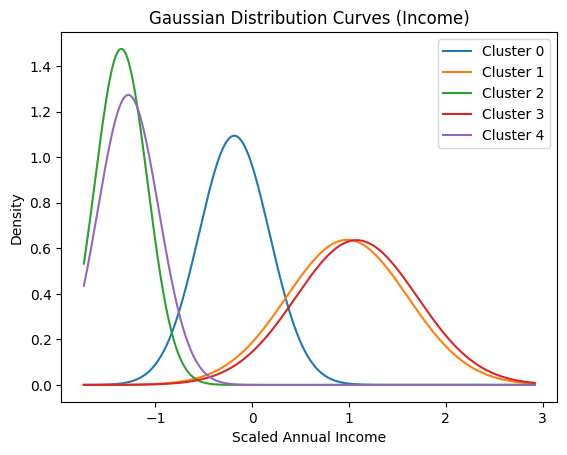

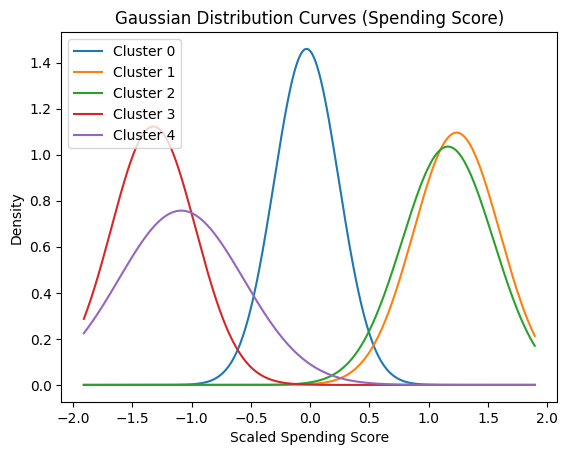

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

# Load Dataset
data = pd.read_csv("/content/Mall_Customers.csv")

# Select Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Extract parameters
means = gmm.means_
covariances = gmm.covariances_

# Plot Gaussian Curves (for 1st feature: Income)
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 500)

plt.figure()

for i in range(len(means)):
    mean = means[i][0]
    std = np.sqrt(covariances[i][0][0])
    y = norm.pdf(x, mean, std)
    plt.plot(x, y, label=f'Cluster {i}')

plt.title("Gaussian Distribution Curves (Income)")
plt.xlabel("Scaled Annual Income")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot Gaussian Curves (for 2nd feature: Spending Score)
x = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 500)

plt.figure()

for i in range(len(means)):
    mean = means[i][1]
    std = np.sqrt(covariances[i][1][1])
    y = norm.pdf(x, mean, std)
    plt.plot(x, y, label=f'Cluster {i}')

plt.title("Gaussian Distribution Curves (Spending Score)")
plt.xlabel("Scaled Spending Score")
plt.ylabel("Density")
plt.legend()
plt.show()

**GMM Distribution**